<a href="https://colab.research.google.com/github/JoaoIvo15/Regressao-Multipla-Energy-Efficiency/blob/main/notebooks/03_diagnostico_e_selecao_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Diagnóstico dos Modelos e Seleção Final

Este notebook dá continuidade à modelagem realizada no Notebook 02 e tem como objetivo avaliar a adequação dos modelos selecionados para as respostas $Y_1$ (Heating Load) e $Y_2$ (Cooling Load).

A análise será concentrada em duas especificações: o Modelo 122 para $Y_1$, formado por $X_3$, $X_5$, $X_7$ e $X_8$, e o Modelo 17 para $Y_2$, formado por $X_1$, $X_5$ e $X_7$.

Serão investigados o comportamento dos resíduos, a homocedasticidade, a normalidade, a independência dos erros, a forma funcional e a presença de observações potencialmente influentes. Caso os diagnósticos indiquem problemas relevantes, serão avaliadas alternativas de transformação e, posteriormente, os modelos serão novamente diagnosticados.

O objetivo é obter especificações adequadas aos dados, justificando as decisões a partir de evidências gráficas e estatísticas.


In [2]:
# Carrega os dados, prepara as variáveis indicadoras e define a função de estimação.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "JoaoIvo15/Regressao-Multipla-Energy-Efficiency/"
    "main/data/raw/ENB2012_data.xlsx"
)

df = pd.read_excel(DATA_URL)

df_model = pd.get_dummies(
    df,
    columns=["X6", "X8"],
    drop_first=True,
    dtype=int
)

variable_columns = {
    "X1": ["X1"],
    "X2": ["X2"],
    "X3": ["X3"],
    "X4": ["X4"],
    "X5": ["X5"],
    "X6": ["X6_3", "X6_4", "X6_5"],
    "X7": ["X7"],
    "X8": ["X8_1", "X8_2", "X8_3", "X8_4", "X8_5"]
}

def fit_mrlm(response, variables):
    columns = []
    for variable in variables:
        columns.extend(variable_columns[variable])
    X = sm.add_constant(df_model[columns])
    y = df_model[response]
    return sm.OLS(y, X).fit()

In [3]:
# Estima os modelos 122 e 17 e resume suas principais medidas de ajuste.
model_specs = {
    "Y1": {"Modelo 122": ["X3", "X5", "X7", "X8"]},
    "Y2": {"Modelo 17": ["X1", "X5", "X7"]}
}

fitted_models = {
    response: {
        model_name: fit_mrlm(response, variables)
        for model_name, variables in models.items()
    }
    for response, models in model_specs.items()
}

model_summary = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        model_summary.append({
            "Resposta": response,
            "Modelo": model_name,
            "Preditores": " + ".join(model_specs[response][model_name]),
            "Observações": int(model.nobs),
            "Parâmetros": len(model.params),
            "R² ajustado": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": np.sqrt(np.mean(model.resid ** 2))
        })

display(pd.DataFrame(model_summary).round(6))

,Resposta,Modelo,Preditores,Observações,Parâmetros,R² ajustado,AIC,BIC,RMSE
0,Y1,Modelo 122,X3 + X5 + X7 + X8,768,9,0.917814,3819.945616,3861.739724,2.875672
1,Y2,Modelo 17,X1 + X5 + X7,768,4,0.881489,4005.658723,4024.233882,3.266450


## 3.1 Resíduos studentizados externamente versus valores ajustados

O gráfico de resíduos studentizados externamente versus valores ajustados será utilizado para investigar possíveis inadequações na especificação dos modelos, especialmente padrões de não linearidade e alterações na dispersão dos resíduos.

Em um modelo adequadamente especificado, espera-se que os pontos estejam distribuídos de maneira aproximadamente aleatória em torno de zero, sem curvaturas ou padrões sistemáticos. Uma dispersão que aumenta ou diminui com os valores ajustados pode indicar possível heterocedasticidade.

Os resíduos studentizados externamente permitem avaliar os desvios individuais em uma escala padronizada, facilitando a identificação de observações que merecem investigação. As referências em ±2 e ±3 serão utilizadas como indicadores exploratórios, e não como critérios automáticos de exclusão.

A análise será realizada separadamente para o Modelo 122, associado à resposta Y1 (Heating Load), e para o Modelo 17, associado à resposta Y2 (Cooling Load). As conclusões visuais serão posteriormente complementadas por testes estatísticos específicos.

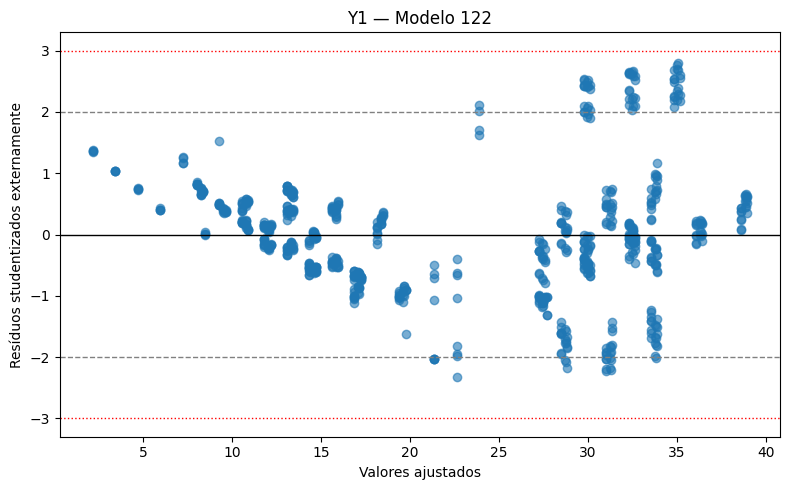

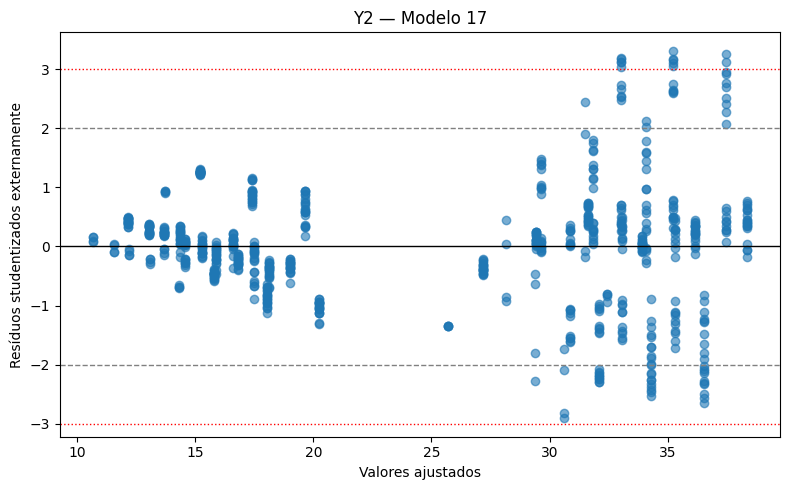

In [4]:
# Plota os resíduos studentizados externamente contra os valores ajustados dos dois modelos selecionados.
for response, models in fitted_models.items():
    for model_name, model in models.items():
        influence = model.get_influence()
        residuals_studentized = influence.resid_studentized_external

        plt.figure(figsize=(8, 5))
        plt.scatter(
            model.fittedvalues,
            residuals_studentized,
            alpha=0.6
        )

        plt.axhline(0, color="black", linewidth=1)
        plt.axhline(2, color="gray", linestyle="--", linewidth=1)
        plt.axhline(-2, color="gray", linestyle="--", linewidth=1)
        plt.axhline(3, color="red", linestyle=":", linewidth=1)
        plt.axhline(-3, color="red", linestyle=":", linewidth=1)

        plt.xlabel("Valores ajustados")
        plt.ylabel("Resíduos studentizados externamente")
        plt.title(f"{response} — {model_name}")
        plt.tight_layout()
        plt.show()

In [5]:
# Aplica o teste de Breusch-Pagan aos dois modelos para avaliar a homocedasticidade.
from statsmodels.stats.diagnostic import het_breuschpagan

alpha = 0.05
hetero_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(
            model.resid,
            model.model.exog,
            robust=True
        )

        hetero_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "Estatística LM": lm_stat,
            "p-valor LM": f"{lm_pvalue:.3e}",
            "Estatística F": f_stat,
            "p-valor F": f"{f_pvalue:.3e}",
            "Conclusão (5%)": (
                "Rejeita homocedasticidade"
                if lm_pvalue < alpha
                else "Não rejeita homocedasticidade"
            )
        })

hetero_table = pd.DataFrame(hetero_results)
display(hetero_table.round(6))

,Resposta,Modelo,Estatística LM,p-valor LM,Estatística F,p-valor F,Conclusão (5%)
0,Y1,Modelo 122,129.270814,4.007e-24,19.201516,1.927e-26,Rejeita homocedasticidade
1,Y2,Modelo 17,148.999021,4.332e-32,61.300523,1.615e-35,Rejeita homocedasticidade


## 3.2 Normalidade dos resíduos

A normalidade dos resíduos será investigada por meio de gráficos Quantile-Quantile (QQ-plots), acompanhados de bandas de referência de 95%, e pelo teste estatístico de Jarque-Bera.

Os QQ-plots serão construídos com os resíduos studentizados externamente. Os quantis observados serão comparados aos quantis teóricos da distribuição normal padrão, enquanto as bandas de referência permitirão avaliar a magnitude dos desvios em relação ao comportamento esperado sob normalidade.

Quando os pontos acompanham aproximadamente a reta de referência e permanecem dentro das bandas, o gráfico não apresenta evidências visuais fortes contra a normalidade. Desvios sistemáticos, especialmente nas caudas, ou pontos fora das bandas podem indicar afastamentos dessa distribuição.

Como complemento, será aplicado o teste de Jarque-Bera aos resíduos do modelo de regressão. Sua hipótese nula corresponde à normalidade, e valores de $p<0{,}05$ levam à rejeição dessa hipótese ao nível de significância de 5%.

As bandas são aproximações pontuais de 95% obtidas por simulação sob normalidade e servem como ferramenta gráfica, não como substitutas do teste estatístico. A conclusão será baseada na análise conjunta dos gráficos e do teste de Jarque-Bera.


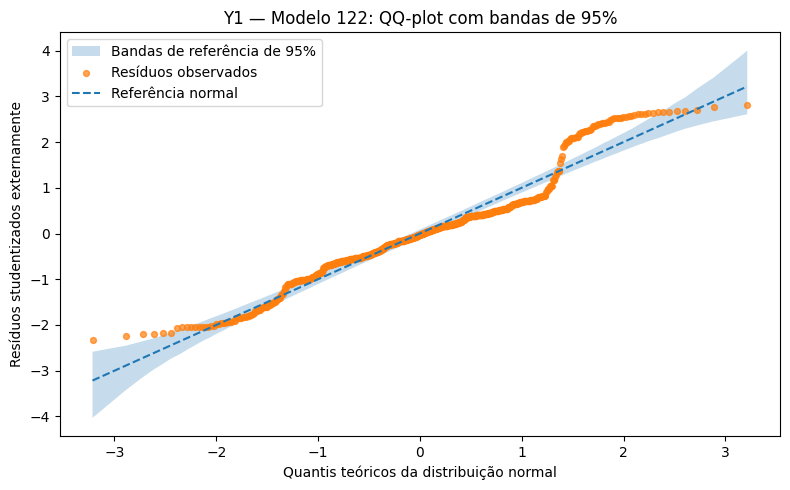

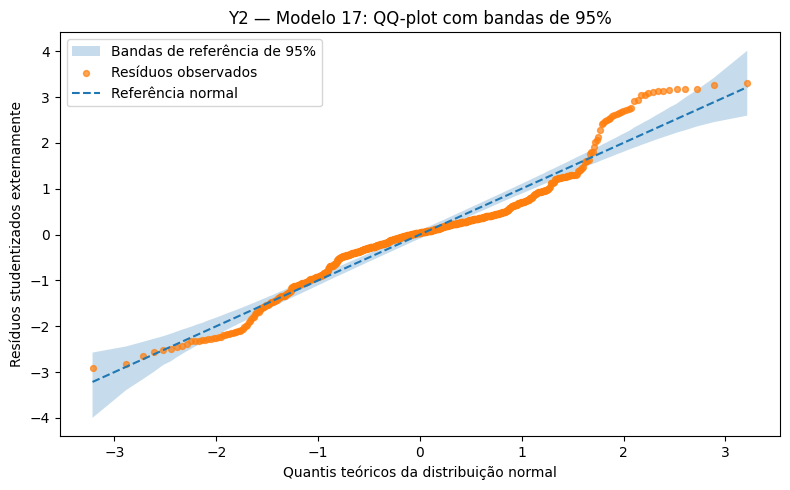

,Resposta,Modelo,Estatística JB,p-valor,Assimetria,Curtose,Conclusão (5%)
0,Y1,Modelo 122,57.376977,0.0,0.521647,3.839385,Rejeita normalidade
1,Y2,Modelo 17,97.514174,0.0,0.294268,4.643455,Rejeita normalidade


In [6]:
# Gera QQ-plots dos resíduos studentizados externamente com bandas de referência de 95% e aplica Jarque-Bera.
from scipy import stats
from statsmodels.stats.stattools import jarque_bera

rng = np.random.default_rng(2026)
normality_results = []

def qqplot_with_bands(residuals, title, n_sim=5000):
    residuals = np.asarray(residuals)
    residuals = residuals[np.isfinite(residuals)]

    n = len(residuals)
    observed = np.sort(residuals)

    # Calcula os quantis teóricos e simula bandas pontuais sob normalidade.
    probabilities = (np.arange(1, n + 1) - 0.5) / n
    theoretical = stats.norm.ppf(probabilities)

    simulated = np.sort(
        rng.standard_normal(size=(n_sim, n)),
        axis=1
    )
    lower_band = np.quantile(simulated, 0.025, axis=0)
    upper_band = np.quantile(simulated, 0.975, axis=0)

    # Desenha o QQ-plot, a reta de referência e as bandas simuladas.
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.fill_between(
        theoretical,
        lower_band,
        upper_band,
        alpha=0.25,
        label="Bandas de referência de 95%"
    )

    ax.scatter(
        theoretical,
        observed,
        s=18,
        alpha=0.7,
        label="Resíduos observados"
    )

    ax.plot(
        theoretical,
        theoretical,
        linestyle="--",
        linewidth=1.5,
        label="Referência normal"
    )

    ax.set_title(title)
    ax.set_xlabel("Quantis teóricos da distribuição normal")
    ax.set_ylabel("Resíduos studentizados externamente")
    ax.legend()
    fig.tight_layout()
    plt.show()


for response, models in fitted_models.items():
    for model_name, model in models.items():
        # Constrói o QQ-plot usando os resíduos studentizados externamente.
        residuals_studentized = model.get_influence().resid_studentized_external

        qqplot_with_bands(
            residuals_studentized,
            f"{response} — {model_name}: QQ-plot com bandas de 95%"
        )

        # Aplica Jarque-Bera aos resíduos OLS originais do modelo.
        jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(model.resid)

        normality_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "Estatística JB": jb_stat,
            "p-valor": jb_pvalue,
            "Assimetria": skewness,
            "Curtose": kurtosis,
            "Conclusão (5%)": (
                "Rejeita normalidade"
                if jb_pvalue < 0.05
                else "Não rejeita normalidade"
            )
        })

normality_table = pd.DataFrame(normality_results)
display(normality_table.round(6))

## 3.3 Independência dos erros

A independência dos erros será investigada por meio da inspeção gráfica dos resíduos studentizados externamente em função da ordem das observações.

Em termos gerais, espera-se que os erros não apresentem dependência sistemática entre as observações. Agrupamentos, sequências persistentes de resíduos positivos ou negativos e outros padrões podem indicar estruturas que merecem investigação.

Entretanto, o conjunto de dados utilizado não constitui uma série temporal, e a ordem das linhas não possui necessariamente um significado temporal ou sequencial. Assim, o gráfico será interpretado apenas como uma ferramenta exploratória, pois eventuais padrões também podem decorrer da organização dos dados.

A avaliação da independência deverá considerar principalmente o processo de geração e organização das observações. Portanto, a inspeção gráfica não será utilizada isoladamente para confirmar ou rejeitar essa hipótese.


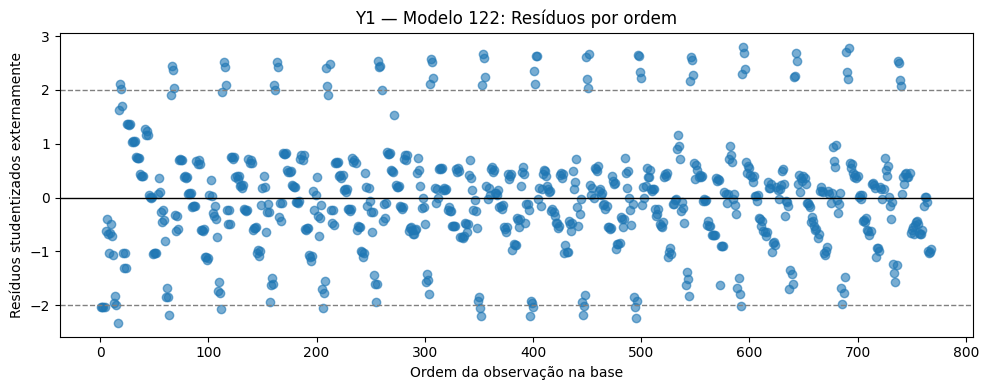

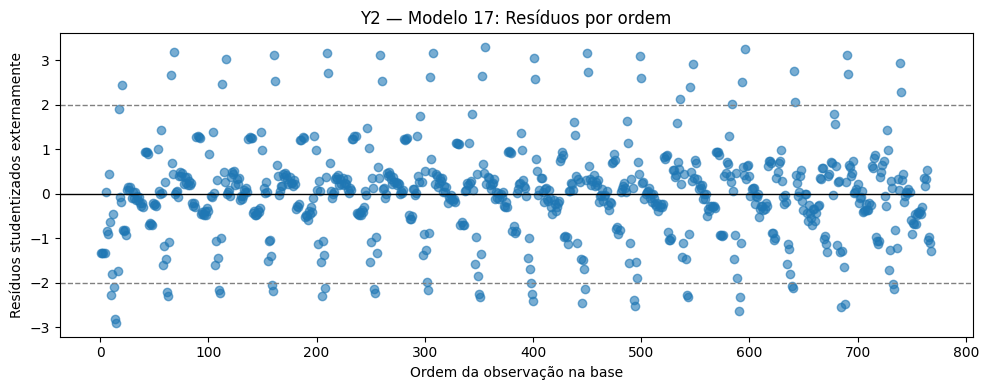

In [7]:
# Plota os resíduos studentizados externamente por ordem das observações para os dois modelos selecionados.
for response, models in fitted_models.items():
    for model_name, model in models.items():
        residuals_studentized = model.get_influence().resid_studentized_external
        observation_order = np.arange(1, len(residuals_studentized) + 1)

        plt.figure(figsize=(10, 4))
        plt.scatter(
            observation_order,
            residuals_studentized,
            alpha=0.6
        )
        plt.axhline(0, color="black", linewidth=1)
        plt.axhline(2, color="gray", linestyle="--", linewidth=1)
        plt.axhline(-2, color="gray", linestyle="--", linewidth=1)

        plt.xlabel("Ordem da observação na base")
        plt.ylabel("Resíduos studentizados externamente")
        plt.title(f"{response} — {model_name}: Resíduos por ordem")
        plt.tight_layout()
        plt.show()

In [8]:
# Avalia a autocorrelação residual com Durbin-Watson e Breusch-Godfrey em diferentes defasagens.
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

alpha = 0.05
independence_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        dw_stat = durbin_watson(model.resid)

        for lag in [1, 2, 5]:
            lm_stat, lm_pvalue, f_stat, f_pvalue = acorr_breusch_godfrey(
                model,
                nlags=lag
            )

            independence_results.append({
                "Resposta": response,
                "Modelo": model_name,
                "Defasagem máxima": lag,
                "Durbin-Watson": round(dw_stat, 4),
                "Estatística LM": round(lm_stat, 4),
                "p-valor LM": f"{lm_pvalue:.3e}",
                "Estatística F": round(f_stat, 4),
                "p-valor F": f"{f_pvalue:.3e}",
                "Conclusão (5%)": (
                    "Rejeita H₀: evidência de autocorrelação"
                    if lm_pvalue < alpha
                    else "Não rejeita H₀"
                )
            })

independence_table = pd.DataFrame(independence_results)
display(independence_table)

/tmp/ipykernel_4131/2350221577.py:13: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  lm_stat, lm_pvalue, f_stat, f_pvalue = acorr_breusch_godfrey(


,Resposta,Modelo,Defasagem máxima,Durbin-Watson,Estatística LM,p-valor LM,Estatística F,p-valor F,Conclusão (5%)
0,Y1,Modelo 122,1,0.6542,348.2106,1.039e-77,628.7526,1.622e-101,Rejeita H₀: evidência de autocorrelação
1,Y1,Modelo 122,2,0.6542,363.2658,1.312e-79,339.7195,5.065e-106,Rejeita H₀: evidência de autocorrelação
2,Y1,Modelo 122,5,0.6542,472.1158,8.318e-100,240.6180,1.815e-153,Rejeita H₀: evidência de autocorrelação
3,Y2,Modelo 17,1,0.9999,191.8244,1.271e-43,254.0233,1.401e-49,Rejeita H₀: evidência de autocorrelação
4,Y2,Modelo 17,2,0.9999,206.0478,1.808e-45,139.6991,2.055e-52,Rejeita H₀: evidência de autocorrelação
5,Y2,Modelo 17,5,0.9999,242.1097,2.709e-50,69.8858,3.838e-60,Rejeita H₀: evidência de autocorrelação


## 3.4 Avaliação da forma funcional

O modelo de Regressão Linear Múltipla deve ser linear nos parâmetros, ou seja, os coeficientes devem aparecer linearmente na expressão matemática do modelo. Isso não impede a inclusão de transformações dos preditores, como termos quadráticos ou logarítmicos, desde que os parâmetros continuem entrando linearmente.

Nesta etapa, será avaliada a adequação da forma funcional adotada para os modelos 122, associado à resposta $Y_1$, e 17, associado à resposta $Y_2$. Para isso, será aplicado o teste de Ramsey RESET, que investiga se a inclusão de termos adicionais construídos a partir dos valores ajustados fornece evidências de possível erro de especificação.

A hipótese nula estabelece que não há evidência de inadequação da forma funcional detectável pelo teste. A hipótese alternativa indica que termos adicionais podem contribuir significativamente para explicar a resposta.

Adotando o nível de significância de 5%, valores de $p<0{,}05$ levam à rejeição da hipótese nula. Como os diagnósticos anteriores apontaram heterocedasticidade, será utilizada uma matriz de covariância robusta HC3. Entretanto, essa correção não trata, por si só, a possível autocorrelação indicada na análise anterior; por isso, os resultados serão interpretados com cautela.

O teste RESET não identifica diretamente qual transformação ou variável deve ser adicionada, nem verifica sozinho todos os pressupostos da regressão. Seus resultados serão considerados em conjunto com os demais diagnósticos.


In [9]:
# Aplica o teste de Ramsey RESET com covariância robusta HC3 aos dois modelos selecionados.
from statsmodels.stats.diagnostic import linear_reset

linearity_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        reset = linear_reset(
            model,
            power=3,
            test_type="fitted",
            use_f=False,
            cov_type="HC3"
        )

        linearity_results.append({
            "Resposta": response,
            "Modelo": model_name,
            "Estatística Wald": float(reset.statistic),
            "p-valor": float(reset.pvalue),
            "Conclusão (5%)": (
                "Rejeita H₀: possível inadequação funcional"
                if reset.pvalue < 0.05
                else "Não rejeita H₀"
            )
        })

linearity_table = pd.DataFrame(linearity_results)
display(linearity_table)

,Resposta,Modelo,Estatística Wald,p-valor,Conclusão (5%)
0,Y1,Modelo 122,192.366174,1.691282e-42,Rejeita H₀: possível inadequação funcional
1,Y2,Modelo 17,32.293143,9.719256e-08,Rejeita H₀: possível inadequação funcional


## 3.5 Diagnóstico de alavancagem, outliers e observações influentes

Nesta etapa, serão investigadas observações que possam apresentar características incomuns ou exercer influência excessiva sobre os modelos selecionados.

Serão utilizadas três medidas complementares:

* **Alavancagem (*leverage*):** identifica observações com configurações incomuns das variáveis explicativas. Será utilizado $2p/n$ como limite de referência, em que $p$ representa o número de parâmetros estimados, incluindo o intercepto, e $n$ é o tamanho da amostra.
* **Resíduos studentizados externamente:** auxiliam na identificação de observações com respostas que apresentam discrepâncias elevadas em relação ao modelo. Valores absolutos superiores a 3 serão utilizados como referência para investigar possíveis outliers.
* **Distância de Cook:** avalia a influência conjunta dos resíduos e da alavancagem sobre as estimativas do modelo. Será utilizado $4/n$ como limite exploratório.

Esses limites não constituem regras automáticas para excluir observações. Os casos sinalizados serão analisados conjuntamente, considerando a qualidade dos dados e o comportamento dos modelos.

A avaliação será realizada para o Modelo 122, associado à resposta $Y_1$, e para o Modelo 17, associado à resposta $Y_2$. Os resultados contribuirão para decidir se os diagnósticos posteriores devem incluir alguma investigação adicional antes da aplicação de transformações.


In [10]:
# Calcula leverage, resíduos studentizados externamente e distância de Cook para os dois modelos selecionados.
influence_summary = []
flagged_observations = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        influence = model.get_influence()

        leverage = influence.hat_matrix_diag
        studentized = influence.resid_studentized_external
        cooks_distance = influence.cooks_distance[0]

        n = int(model.nobs)
        p = len(model.params)

        leverage_limit = 2 * p / n
        cook_limit = 4 / n

        high_leverage = leverage > leverage_limit
        possible_outlier = np.abs(studentized) > 3
        influential = cooks_distance > cook_limit

        influence_summary.append({
            "Resposta": response,
            "Modelo": model_name,
            "Maior leverage": np.max(leverage),
            "Limite leverage (2p/n)": leverage_limit,
            "Casos com leverage elevado": int(high_leverage.sum()),
            "Maior |resíduo studentizado|": np.max(np.abs(studentized)),
            "Casos com |resíduo| > 3": int(possible_outlier.sum()),
            "Maior distância de Cook": np.max(cooks_distance),
            "Limite Cook (4/n)": cook_limit,
            "Casos com Cook > 4/n": int(influential.sum())
        })

        for i in range(n):
            if high_leverage[i] or possible_outlier[i] or influential[i]:
                flagged_observations.append({
                    "Resposta": response,
                    "Modelo": model_name,
                    "Observação (linha)": i + 1,
                    "Leverage": leverage[i],
                    "Resíduo studentizado externo": studentized[i],
                    "Distância de Cook": cooks_distance[i],
                    "Leverage elevado": high_leverage[i],
                    "|Resíduo| > 3": possible_outlier[i],
                    "Cook > 4/n": influential[i]
                })

influence_summary = pd.DataFrame(influence_summary)
flagged_observations = pd.DataFrame(flagged_observations)

print("Resumo dos diagnósticos:")
display(influence_summary.round(5))

print("Observações sinalizadas por pelo menos um critério:")
if not flagged_observations.empty:
    display(
        flagged_observations
        .sort_values(
            ["Resposta", "Distância de Cook"],
            ascending=[True, False]
        )
        .round(5)
        .reset_index(drop=True)
    )
else:
    print("Nenhuma observação foi sinalizada pelos limites utilizados.")

Resumo dos diagnósticos:


,Resposta,Modelo,Maior leverage,Limite leverage (2p/n),Casos com leverage elevado,Maior |resíduo studentizado|,Casos com |resíduo| > 3,Maior distância de Cook,Limite Cook (4/n),Casos com Cook > 4/n
0,Y1,Modelo 122,0.02760,0.02344,12,2.80552,0,0.01363,0.00521,58
1,Y2,Modelo 17,0.01274,0.01042,24,3.30949,12,0.01593,0.00521,57


Observações sinalizadas por pelo menos um critério:


,Resposta,Modelo,Observação (linha),Leverage,Resíduo studentizado externo,Distância de Cook,Leverage elevado,|Resíduo| > 3,Cook > 4/n
0,Y1,Modelo 122,16,0.02225,-2.32892,0.01363,False,False,True
1,Y1,Modelo 122,18,0.02225,2.10662,0.01117,False,False,True
2,Y1,Modelo 122,1,0.02314,-2.03505,0.01086,False,False,True
3,Y1,Modelo 122,3,0.02314,-2.03505,0.01086,False,False,True
4,Y1,Modelo 122,2,0.02314,-2.03505,0.01086,False,False,True
...,...,...,...,...,...,...,...,...,...
137,Y2,Modelo 17,577,0.01071,0.40797,0.00045,True,False,False
138,Y2,Modelo 17,673,0.01071,0.40490,0.00044,True,False,False
139,Y2,Modelo 17,721,0.01071,0.38342,0.00040,True,False,False
140,Y2,Modelo 17,531,0.01071,0.36807,0.00037,True,False,False


### 3.5.1 Investigação das observações sinalizadas

Os resultados iniciais identificaram observações com potencial de alavancagem, discrepâncias residuais e influência sobre as estimativas. Entretanto, esses indicadores têm funções distintas e não devem ser utilizados isoladamente para justificar a exclusão de casos.

Nesta etapa, serão examinadas as observações com maiores distâncias de Cook e os casos com resíduos studentizados externamente em valor absoluto superiores a 3. O objetivo é verificar quais observações merecem investigação mais detalhada antes de decidir sobre eventuais alterações nos modelos.

A identificação de uma observação influente não implica necessariamente erro de medição ou inadequação dos dados. Por isso, os resultados serão utilizados como instrumento de investigação, e não como critério automático de exclusão.


In [11]:
# Lista as dez maiores distâncias de Cook por modelo e todos os casos com resíduos studentizados externos acima de 3.
top_cook_results = []
outlier_results = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        influence = model.get_influence()

        leverage = influence.hat_matrix_diag
        studentized = influence.resid_studentized_external
        cooks_d = influence.cooks_distance[0]

        n = int(model.nobs)
        leverage_limit = 2 * len(model.params) / n
        cook_limit = 4 / n

        diagnostics = pd.DataFrame({
            "Observação (linha)": np.arange(1, n + 1),
            "Leverage": leverage,
            "Resíduo studentizado externo": studentized,
            "Distância de Cook": cooks_d
        })

        diagnostics["Alavancagem elevada"] = (
            diagnostics["Leverage"] > leverage_limit
        )
        diagnostics["|Resíduo| > 3"] = (
            diagnostics["Resíduo studentizado externo"].abs() > 3
        )
        diagnostics["Cook > 4/n"] = (
            diagnostics["Distância de Cook"] > cook_limit
        )

        # Seleciona os dez casos com maior distância de Cook em cada modelo.
        top_cook = diagnostics.nlargest(10, "Distância de Cook").copy()
        top_cook.insert(0, "Modelo", model_name)
        top_cook.insert(0, "Resposta", response)
        top_cook_results.append(top_cook)

        # Registra todos os casos com resíduos studentizados externos acima de 3.
        outliers = diagnostics[diagnostics["|Resíduo| > 3"]].copy()
        if not outliers.empty:
            outliers.insert(0, "Modelo", model_name)
            outliers.insert(0, "Resposta", response)
            outlier_results.append(outliers)

top_cook_table = pd.concat(top_cook_results, ignore_index=True)
display(
    top_cook_table.round(5)
    .sort_values(["Resposta", "Distância de Cook"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Observações com |resíduo studentizado externo| > 3:")
if outlier_results:
    outlier_table = pd.concat(outlier_results, ignore_index=True)
    display(outlier_table.round(5))
else:
    print("Nenhuma observação ultrapassou esse limite nos modelos avaliados.")

,Resposta,Modelo,Observação (linha),Leverage,Resíduo studentizado externo,Distância de Cook,Alavancagem elevada,|Resíduo| > 3,Cook > 4/n
0,Y1,Modelo 122,16,0.02225,-2.32892,0.01363,False,False,True
1,Y1,Modelo 122,18,0.02225,2.10662,0.01117,False,False,True
2,Y1,Modelo 122,1,0.02314,-2.03505,0.01086,False,False,True
3,Y1,Modelo 122,3,0.02314,-2.03505,0.01086,False,False,True
4,Y1,Modelo 122,2,0.02314,-2.03505,0.01086,False,False,True
5,Y1,Modelo 122,4,0.02314,-2.03505,0.01086,False,False,True
6,Y1,Modelo 122,19,0.02225,2.01149,0.01019,False,False,True
7,Y1,Modelo 122,15,0.02225,-1.98689,0.00994,False,False,True
8,Y1,Modelo 122,13,0.02225,-1.95168,0.00959,False,False,True
9,Y1,Modelo 122,594,0.01044,2.80552,0.00915,False,False,True


Observações com |resíduo studentizado externo| > 3:


,Resposta,Modelo,Observação (linha),Leverage,Resíduo studentizado externo,Distância de Cook,Alavancagem elevada,|Resíduo| > 3,Cook > 4/n
0,Y2,Modelo 17,68,0.00534,3.18137,0.01342,False,True,True
1,Y2,Modelo 17,116,0.00534,3.03482,0.01223,False,True,True
2,Y2,Modelo 17,161,0.00534,3.11586,0.01288,False,True,True
3,Y2,Modelo 17,210,0.00534,3.17200,0.01334,False,True,True
4,Y2,Modelo 17,259,0.00534,3.12209,0.01293,False,True,True
5,Y2,Modelo 17,308,0.00403,3.16905,0.01004,False,True,True
6,Y2,Modelo 17,356,0.00403,3.30949,0.01094,False,True,True
7,Y2,Modelo 17,401,0.00403,3.04753,0.00929,False,True,True
8,Y2,Modelo 17,450,0.00403,3.15658,0.00996,False,True,True
9,Y2,Modelo 17,499,0.00403,3.09425,0.00958,False,True,True


### 3.5.2 Investigação das observações potencialmente influentes

As observações identificadas pelos resíduos studentizados externamente e pela distância de Cook serão examinadas em conjunto com seus valores originais. O objetivo é verificar se os casos sinalizados correspondem a erros nos dados ou a configurações válidas que não são bem representadas pelas especificações atuais.

Para manter a análise objetiva, serão inspecionadas as dez observações com maiores distâncias de Cook de cada modelo e todas as observações com resíduos studentizados externamente em valor absoluto superiores a 3.

Essa investigação não implica a exclusão automática de registros. As observações serão mantidas, a menos que seja identificada uma justificativa concreta para corrigir ou excluir algum dado.


In [12]:
# Confronta os casos de maior distância de Cook e os resíduos extremos com os valores originais da base.
observations_to_inspect = []

predictor_columns = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]

for response, models in fitted_models.items():
    for model_name, model in models.items():
        influence = model.get_influence()

        diagnostics = pd.DataFrame({
            "Observação": np.arange(1, len(model.resid) + 1),
            "Valor ajustado": np.asarray(model.fittedvalues),
            "Resíduo bruto": np.asarray(model.resid),
            "Resíduo studentizado externo": influence.resid_studentized_external,
            "Leverage": influence.hat_matrix_diag,
            "Distância de Cook": influence.cooks_distance[0]
        })

        top_cook = set(
            diagnostics.nlargest(10, "Distância de Cook")["Observação"]
        )
        extreme_residuals = set(
            diagnostics.loc[
                diagnostics["Resíduo studentizado externo"].abs() > 3,
                "Observação"
            ]
        )
        selected_rows = top_cook | extreme_residuals

        for row_number in sorted(selected_rows):
            diagnostic_row = diagnostics.loc[
                diagnostics["Observação"] == row_number
            ].iloc[0]

            original_row = df.iloc[int(row_number) - 1]

            record = {
                "Resposta": response,
                "Modelo": model_name,
                "Observação": int(row_number),
                **original_row[predictor_columns].to_dict(),
                "Valor observado": original_row[response],
                "Valor ajustado": diagnostic_row["Valor ajustado"],
                "Resíduo bruto": diagnostic_row["Resíduo bruto"],
                "Resíduo studentizado externo": diagnostic_row[
                    "Resíduo studentizado externo"
                ],
                "Leverage": diagnostic_row["Leverage"],
                "Distância de Cook": diagnostic_row["Distância de Cook"],
                "Entre os 10 maiores Cook": row_number in top_cook,
                "|Resíduo studentizado| > 3": row_number in extreme_residuals
            }

            observations_to_inspect.append(record)

observations_to_inspect = pd.DataFrame(observations_to_inspect)

display(
    observations_to_inspect
    .sort_values(
        ["Resposta", "Distância de Cook"],
        ascending=[True, False]
    )
    .round(4)
    .reset_index(drop=True)
)

,Resposta,Modelo,Observação,X1,X2,X3,X4,X5,X6,X7,X8,Valor observado,Valor ajustado,Resíduo bruto,Resíduo studentizado externo,Leverage,Distância de Cook,Entre os 10 maiores Cook,|Resíduo studentizado| > 3
0,Y1,Modelo 122,16,0.82,612.5,318.5,147.00,7.0,5.0,0.00,0.0,15.98,22.6221,-6.6421,-2.3289,0.0222,0.0136,True,False
1,Y1,Modelo 122,18,0.79,637.0,343.0,147.00,7.0,3.0,0.00,0.0,29.90,23.8880,6.0120,2.1066,0.0222,0.0112,True,False
2,Y1,Modelo 122,1,0.98,514.5,294.0,110.25,7.0,2.0,0.00,0.0,15.55,21.3562,-5.8062,-2.0350,0.0231,0.0109,True,False
3,Y1,Modelo 122,3,0.98,514.5,294.0,110.25,7.0,4.0,0.00,0.0,15.55,21.3562,-5.8062,-2.0350,0.0231,0.0109,True,False
4,Y1,Modelo 122,2,0.98,514.5,294.0,110.25,7.0,3.0,0.00,0.0,15.55,21.3562,-5.8062,-2.0350,0.0231,0.0109,True,False
5,Y1,Modelo 122,4,0.98,514.5,294.0,110.25,7.0,5.0,0.00,0.0,15.55,21.3562,-5.8062,-2.0350,0.0231,0.0109,True,False
6,Y1,Modelo 122,19,0.79,637.0,343.0,147.00,7.0,4.0,0.00,0.0,29.63,23.8880,5.7420,2.0115,0.0222,0.0102,True,False
7,Y1,Modelo 122,15,0.82,612.5,318.5,147.00,7.0,4.0,0.00,0.0,16.95,22.6221,-5.6721,-1.9869,0.0222,0.0099,True,False
8,Y1,Modelo 122,13,0.82,612.5,318.5,147.00,7.0,2.0,0.00,0.0,17.05,22.6221,-5.5721,-1.9517,0.0222,0.0096,True,False
9,Y1,Modelo 122,594,0.79,637.0,343.0,147.00,7.0,3.0,0.40,2.0,43.10,35.0633,8.0367,2.8055,0.0104,0.0091,True,False


### 3.5.3 Padrões residuais associados à geometria

A análise das observações potencialmente influentes identificou, principalmente no modelo associado à resposta $Y_2$, vários resíduos positivos elevados associados a uma mesma configuração geométrica.

Para investigar se esse comportamento representa um padrão sistemático de inadequação do modelo, serão analisados os resíduos agrupados pelas variáveis geométricas $X_1$, $X_3$, $X_4$ e $X_5$.

Serão comparados o número de observações, o resíduo médio, a raiz do erro quadrático médio residual e a magnitude dos resíduos studentizados externamente em cada grupo. Essa avaliação permitirá distinguir observações isoladas de grupos de configurações para os quais o modelo apresenta erros sistemáticos.

A análise é exploratória e não implica a exclusão de registros. Seu objetivo é fornecer evidências adicionais para decidir se será necessário rever os preditores ou a forma funcional antes de considerar transformações da resposta.

In [13]:
# Resume os resíduos por configuração geométrica e destaca os grupos com maiores desvios médios.
geometry_results = []

geometry_columns = ["X1", "X3", "X4", "X5"]

for response, models in fitted_models.items():
    for model_name, model in models.items():
        grouped_data = df[geometry_columns].copy()
        grouped_data["Resíduo"] = np.asarray(model.resid)
        grouped_data["Resíduo studentizado externo"] = (
            model.get_influence().resid_studentized_external
        )

        summary = (
            grouped_data
            .groupby(geometry_columns, as_index=False)
            .agg(
                Número_de_observações=("Resíduo", "size"),
                Resíduo_médio=("Resíduo", "mean"),
                RMSE_residual=(
                    "Resíduo",
                    lambda values: np.sqrt(np.mean(values ** 2))
                ),
                Média_abs_studentizado=(
                    "Resíduo studentizado externo",
                    lambda values: np.mean(np.abs(values))
                ),
                Máximo_abs_studentizado=(
                    "Resíduo studentizado externo",
                    lambda values: np.max(np.abs(values))
                )
            )
        )

        summary.insert(0, "Modelo", model_name)
        summary.insert(0, "Resposta", response)
        summary["Módulo_resíduo_médio"] = summary["Resíduo_médio"].abs()

        geometry_results.append(summary)

geometry_summary = pd.concat(geometry_results, ignore_index=True)

for response in ["Y1", "Y2"]:
    print(f"Configurações com maiores resíduos médios absolutos — {response}")

    display(
        geometry_summary.loc[geometry_summary["Resposta"] == response]
        .sort_values("Módulo_resíduo_médio", ascending=False)
        .head(10)
        .drop(columns="Módulo_resíduo_médio")
        .round(4)
        .reset_index(drop=True)
    )

Configurações com maiores resíduos médios absolutos — Y1


,Resposta,Modelo,X1,X3,X4,X5,Número_de_observações,Resíduo_médio,RMSE_residual,Média_abs_studentizado,Máximo_abs_studentizado
0,Y1,Modelo 122,0.79,343.0,147.00,7.0,64,6.6991,6.7427,2.3351,2.8055
1,Y1,Modelo 122,0.82,318.5,147.00,7.0,64,-5.0876,5.1398,1.7709,2.3289
2,Y1,Modelo 122,0.62,367.5,220.50,3.5,64,-2.2200,2.3699,0.7737,1.6232
3,Y1,Modelo 122,0.98,294.0,110.25,7.0,64,-1.7308,2.4002,0.6497,2.0350
4,Y1,Modelo 122,0.74,245.0,220.50,3.5,64,1.7130,1.8591,0.5963,1.3721
5,Y1,Modelo 122,0.64,343.0,220.50,3.5,64,1.3780,1.6210,0.4869,1.2714
6,Y1,Modelo 122,0.66,318.5,220.50,3.5,64,-1.1547,1.4276,0.4519,0.7480
7,Y1,Modelo 122,0.90,318.5,122.50,7.0,64,0.9860,1.5467,0.4611,1.1648
8,Y1,Modelo 122,0.86,294.0,147.00,7.0,64,-0.8244,1.0648,0.2922,1.0656
9,Y1,Modelo 122,0.71,269.5,220.50,3.5,64,0.6004,1.2538,0.3113,1.5325


Configurações com maiores resíduos médios absolutos — Y2


,Resposta,Modelo,X1,X3,X4,X5,Número_de_observações,Resíduo_médio,RMSE_residual,Média_abs_studentizado,Máximo_abs_studentizado
0,Y2,Modelo 17,0.82,318.5,147.0,7.0,64,-6.0452,6.2832,1.8538,2.9068
1,Y2,Modelo 17,0.79,343.0,147.0,7.0,64,5.2478,6.5403,1.6209,3.3095
2,Y2,Modelo 17,0.64,343.0,220.5,3.5,64,3.0335,3.1768,0.9283,1.3096
3,Y2,Modelo 17,0.62,367.5,220.5,3.5,64,-2.5618,2.6869,0.7841,1.3052
4,Y2,Modelo 17,0.90,318.5,122.5,7.0,64,2.1961,3.2068,0.7577,2.1209
5,Y2,Modelo 17,0.86,294.0,147.0,7.0,64,-1.9370,3.2483,0.7927,2.2752
6,Y2,Modelo 17,0.66,318.5,220.5,3.5,64,-0.7117,0.8781,0.2420,0.6106
7,Y2,Modelo 17,0.74,245.0,220.5,3.5,64,0.6769,0.9166,0.2338,0.5044
8,Y2,Modelo 17,0.76,416.5,122.5,7.0,64,0.4974,1.2276,0.2833,0.9317
9,Y2,Modelo 17,0.69,294.0,220.5,3.5,64,-0.4211,0.9604,0.2493,0.6968


### 3.5.4 Análise de sensibilidade das estimativas

A identificação de observações com elevada distância de Cook ou resíduos studentizados extremos não é suficiente, isoladamente, para justificar sua exclusão. É necessário avaliar em que medida a retirada de uma observação poderia alterar as estimativas dos coeficientes.

Para complementar a análise anterior, serão examinadas as medidas **DFBETAS**, que quantificam a mudança padronizada nas estimativas dos coeficientes associada à retirada individual de cada observação. Valores elevados indicam casos que merecem atenção por seu possível impacto sobre parâmetros específicos.

Será utilizado o limite exploratório $2/\sqrt{n}$ para sinalizar valores potencialmente relevantes. Esse limite é uma referência, não um critério automático de exclusão. A análise será interpretada em conjunto com a distância de Cook, os resíduos studentizados e os padrões identificados por configuração geométrica.

O objetivo é avaliar a sensibilidade das estimativas, mantendo inicialmente todas as observações. A exclusão definitiva de registros dependerá de evidências concretas de erro nos dados ou de outra justificativa metodológica defensável.

In [18]:
# Avalia a influência individual sobre os coeficientes por meio das medidas DFBETAS.
dfbetas_summary = []
dfbetas_top_cases = []

for response, models in fitted_models.items():
    for model_name, model in models.items():
        influence = model.get_influence()

        # Calcula a maior mudança padronizada associada a cada observação.
        dfbetas = np.asarray(influence.dfbetas)
        abs_dfbetas = np.abs(dfbetas)
        max_abs_dfbeta = np.nanmax(abs_dfbetas, axis=1)
        most_affected_param = [
            model.model.exog_names[np.nanargmax(row)]
            for row in abs_dfbetas
        ]

        n = int(model.nobs)
        reference_limit = 2 / np.sqrt(n)

        # Resume a quantidade de casos que ultrapassa o limite exploratório.
        dfbetas_summary.append({
            "Resposta": response,
            "Modelo": model_name,
            "Limite de referência": reference_limit,
            "Maior |DFBETAS|": np.nanmax(max_abs_dfbeta),
            "Casos acima do limite": int(
                np.sum(max_abs_dfbeta > reference_limit)
            )
        })

        # Lista as dez observações com maior impacto padronizado nos coeficientes.
        top_indices = np.argsort(max_abs_dfbeta)[::-1][:10]
        cooks_distance = influence.cooks_distance[0]
        studentized = influence.resid_studentized_external

        for i in top_indices:
            dfbetas_top_cases.append({
                "Resposta": response,
                "Modelo": model_name,
                "Observação (linha)": int(i + 1),
                "Parâmetro mais afetado": most_affected_param[i],
                "Maior |DFBETAS|": max_abs_dfbeta[i],
                "Limite de referência": reference_limit,
                "Acima do limite": max_abs_dfbeta[i] > reference_limit,
                "Resíduo studentizado externo": studentized[i],
                "Distância de Cook": cooks_distance[i]
            })

dfbetas_summary = pd.DataFrame(dfbetas_summary)
dfbetas_top_cases = pd.DataFrame(dfbetas_top_cases)

print("Resumo da sensibilidade dos coeficientes:")
display(dfbetas_summary.round(5))

print("Dez observações com maior impacto padronizado em cada modelo:")
display(
    dfbetas_top_cases
    .sort_values(
        ["Resposta", "Maior |DFBETAS|"],
        ascending=[True, False]
    )
    .round(5)
    .reset_index(drop=True)
)

Resumo da sensibilidade dos coeficientes:


,Resposta,Modelo,Limite de referência,Maior |DFBETAS|,Casos acima do limite
0,Y1,Modelo 122,0.07217,0.26783,142
1,Y2,Modelo 17,0.07217,0.18530,79


Dez observações com maior impacto padronizado em cada modelo:


,Resposta,Modelo,Observação (linha),Parâmetro mais afetado,Maior |DFBETAS|,Limite de referência,Acima do limite,Resíduo studentizado externo,Distância de Cook
0,Y1,Modelo 122,16,X8_2,0.26783,0.07217,True,-2.32892,0.01363
1,Y1,Modelo 122,18,X8_3,0.24226,0.07217,True,2.10662,0.01117
2,Y1,Modelo 122,2,X8_2,0.23414,0.07217,True,-2.03505,0.01086
3,Y1,Modelo 122,3,X8_2,0.23414,0.07217,True,-2.03505,0.01086
4,Y1,Modelo 122,1,X8_2,0.23414,0.07217,True,-2.03505,0.01086
5,Y1,Modelo 122,4,X8_2,0.23414,0.07217,True,-2.03505,0.01086
6,Y1,Modelo 122,19,X8_3,0.23132,0.07217,True,2.01149,0.01019
7,Y1,Modelo 122,15,X8_2,0.22849,0.07217,True,-1.98689,0.00994
8,Y1,Modelo 122,13,X8_2,0.22445,0.07217,True,-1.95168,0.00959
9,Y1,Modelo 122,14,X8_2,0.20988,0.07217,True,-1.82501,0.00839


#### 3.5.5 Sensibilidade dos coeficientes à retirada individual de observações

Os resultados de DFBETAS identificaram diferentes observações com potencial para alterar as estimativas dos coeficientes. Para aprofundar essa investigação, serão selecionados casos representativos segundo três critérios: maior influência padronizada sobre os coeficientes, maior resíduo studentizado externo em módulo e maior distância de Cook.

Para cada caso selecionado, o modelo será reajustado temporariamente sem a observação correspondente, mantendo-se todos os demais registros. Serão comparados os coeficientes estimados com a base completa e com a retirada individual do caso.

Essa comparação permitirá avaliar a magnitude e a direção das alterações nas estimativas. As observações serão utilizadas apenas para análise de sensibilidade e não serão excluídas definitivamente nesta etapa.

In [20]:
# Compara os coeficientes dos modelos completos com os obtidos após retirar temporariamente cada caso selecionado.
selected_cases = {
    "Y1": {
        "Modelo 122": [16, 18, 594]
    },
    "Y2": {
        "Modelo 17": [15, 356, 596]
    }
}

sensitivity_results = []

for response, models in selected_cases.items():
    for model_name, observations in models.items():
        model = fitted_models[response][model_name]

        # Recupera a matriz de preditores e a resposta na ordem original das observações.
        X = np.asarray(model.model.exog)
        y = np.asarray(model.model.endog)
        parameter_names = model.model.exog_names
        original_params = np.asarray(model.params)

        influence = model.get_influence()
        dfbetas = np.asarray(influence.dfbetas)
        n = len(y)
        reference_limit = 2 / np.sqrt(n)

        for observation in observations:
            # Reestima o modelo sem uma única observação, sem alterar a base original.
            index = observation - 1
            keep = np.arange(n) != index
            model_without_case = sm.OLS(y[keep], X[keep]).fit()
            params_without_case = np.asarray(model_without_case.params)

            # Prioriza os coeficientes cujo DFBETAS ultrapassou o limite de referência.
            case_dfbetas = np.abs(dfbetas[index])
            affected_parameters = np.where(
                case_dfbetas > reference_limit
            )[0]

            # Se nenhum coeficiente ultrapassar o limite, registra o mais afetado.
            if len(affected_parameters) == 0:
                affected_parameters = [int(np.argmax(case_dfbetas))]

            for j in affected_parameters:
                original_value = original_params[j]
                new_value = params_without_case[j]

                sensitivity_results.append({
                    "Resposta": response,
                    "Modelo": model_name,
                    "Observação retirada temporariamente": observation,
                    "Coeficiente": parameter_names[j],
                    "DFBETAS": dfbetas[index, j],
                    "Acima do limite": (
                        abs(dfbetas[index, j]) > reference_limit
                    ),
                    "Coeficiente com todos os dados": original_value,
                    "Coeficiente sem a observação": new_value,
                    "Variação do coeficiente (sem caso - completo)": new_value - original_value,
                    "Mudou de sinal": original_value * new_value < 0
                })

sensitivity_table = pd.DataFrame(sensitivity_results)

display(
    sensitivity_table
    .sort_values(
        ["Resposta", "Observação retirada temporariamente", "DFBETAS"],
        ascending=[True, True, False]
    )
    .round(5)
    .reset_index(drop=True)
)

,Resposta,Modelo,Observação retirada temporariamente,Coeficiente,DFBETAS,Acima do limite,Coeficiente com todos os dados,Coeficiente sem a observação,Variação do coeficiente (sem caso - completo),Mudou de sinal
0,Y1,Modelo 122,16,X8_2,0.26783,True,4.43599,4.29446,-0.14153,False
1,Y1,Modelo 122,16,X8_5,0.26783,True,4.18244,4.04092,-0.14153,False
2,Y1,Modelo 122,16,X8_3,0.26783,True,4.18300,4.04147,-0.14153,False
3,Y1,Modelo 122,16,X8_1,0.26783,True,4.52765,4.38613,-0.14153,False
4,Y1,Modelo 122,16,X8_4,0.26783,True,4.38821,4.24668,-0.14153,False
5,Y1,Modelo 122,16,X5,-0.08856,True,4.76328,4.76877,0.00549,False
6,Y1,Modelo 122,16,const,-0.15171,True,-27.17752,-27.04509,0.13243,False
7,Y1,Modelo 122,18,const,0.10109,True,-27.17752,-27.26582,-0.08830,False
8,Y1,Modelo 122,18,X8_2,-0.24226,True,4.43599,4.56409,0.12810,False
9,Y1,Modelo 122,18,X8_1,-0.24226,True,4.52765,4.65575,0.12810,False


### Síntese e decisão sobre as observações potencialmente influentes

A análise de influência identificou observações que merecem atenção nos dois modelos. Pelo critério exploratório de DFBETAS, 142 casos foram sinalizados para o modelo de $Y_1$ e 79 para o modelo de $Y_2$. Esse resultado indica que diferentes observações podem afetar as estimativas de determinados coeficientes, mas não constitui, isoladamente, justificativa para excluir registros.

Como verificação complementar, foram reajustados os modelos após a retirada temporária, uma observação por vez, de casos selecionados por influência nos coeficientes, magnitude dos resíduos studentizados e distância de Cook. Nos casos examinados, as alterações nas estimativas foram relativamente pequenas em comparação com a magnitude dos coeficientes explicativos, sem mudança de sinal. Essa conclusão se restringe aos casos selecionados e não permite afirmar que todas as combinações de exclusão teriam efeitos igualmente pequenos.

Não foram identificadas evidências concretas de erros nos registros que justificassem sua exclusão. Assim, todas as observações serão mantidas nas análises subsequentes. Essa decisão não implica que os modelos estejam adequadamente especificados: os padrões residuais associados a determinadas configurações geométricas e os problemas apontados pelos diagnósticos continuam sendo questões relevantes para as etapas seguintes.

## 3.6 Transformação das respostas pelo método Box–Cox

Os diagnósticos anteriores identificaram evidências de heterocedasticidade e desvios da normalidade nos modelos selecionados. Além disso, o teste de Ramsey RESET indicou possível inadequação da forma funcional.

Nesta etapa, será investigada a transformação Box–Cox das variáveis resposta $Y_1$ e $Y_2$, mantendo inicialmente os preditores dos Modelos 122 e 17. O parâmetro da transformação será estimado por máxima verossimilhança perfilada, considerando a estrutura de regressão de cada modelo.

Para respostas positivas, a transformação é definida por:

$$
Y^{(\lambda)}=
\begin{cases}
\dfrac{Y^\lambda-1}{\lambda}, & \lambda\neq 0,\\[6pt]
\ln(Y), & \lambda=0.
\end{cases}
$$

O parâmetro $\lambda$ determina a transformação aplicada. Após a estimação, serão reavaliadas a homocedasticidade, a normalidade dos resíduos e a forma funcional.

A transformação será considerada uma alternativa a investigar, não uma garantia de correção dos problemas encontrados. Os resultados deverão ser comparados aos diagnósticos anteriores, e qualquer inadequação persistente será analisada separadamente.

In [15]:
# Estima a transformação Box-Cox por máxima verossimilhança perfilada e reavalia três diagnósticos dos modelos.
from scipy.optimize import minimize_scalar

def boxcox_transform(y, lam):
    y = np.asarray(y, dtype=float)
    if abs(lam) < 1e-7:
        return np.log(y)
    return (y**lam - 1) / lam

boxcox_specs = {
    "Y1": ["X3", "X5", "X7", "X8"],
    "Y2": ["X1", "X5", "X7"]
}

boxcox_models = {}
boxcox_lambdas = {}
boxcox_results = []

for response, variables in boxcox_specs.items():
    y = df[response].to_numpy(dtype=float)

    if np.any(y <= 0):
        raise ValueError(f"A resposta {response} contém valores não positivos.")

    columns = []
    for variable in variables:
        columns.extend(variable_columns[variable])

    X = sm.add_constant(df_model[columns].astype(float))
    log_y_sum = np.log(y).sum()
    n = len(y)

    def negative_profile_loglik(lam):
        transformed_y = boxcox_transform(y, lam)
        fitted = sm.OLS(transformed_y, X).fit()
        sse = np.sum(fitted.resid**2)

        if not np.isfinite(sse) or sse <= 0:
            return np.inf

        profile_loglik = (
            -(n / 2) * np.log(sse / n)
            + (lam - 1) * log_y_sum
        )
        return -profile_loglik

    optimization = minimize_scalar(
        negative_profile_loglik,
        bounds=(-2, 2),
        method="bounded",
        options={"xatol": 1e-7}
    )

    lam = float(optimization.x)
    transformed_y = boxcox_transform(y, lam)
    model_transformed = sm.OLS(transformed_y, X).fit()

    boxcox_lambdas[response] = lam
    boxcox_models[response] = model_transformed

    bp = het_breuschpagan(
        model_transformed.resid,
        model_transformed.model.exog,
        robust=True
    )
    jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(
        model_transformed.resid
    )
    reset = linear_reset(
        model_transformed,
        power=3,
        test_type="fitted",
        use_f=False,
        cov_type="HC3"
    )

    boxcox_results.append({
        "Resposta": response,
        "Modelo": "122" if response == "Y1" else "17",
        "Lambda estimado": lam,
        "Lambda próximo da fronteira": abs(lam) > 1.95,
        "p-valor Breusch-Pagan": f"{bp[1]:.3e}",
        "p-valor Jarque-Bera": f"{jb_pvalue:.3e}",
        "Assimetria residual": skewness,
        "Curtose residual": kurtosis,
        "p-valor RESET HC3": f"{float(reset.pvalue):.3e}"
    })

display(pd.DataFrame(boxcox_results).round(6))

,Resposta,Modelo,Lambda estimado,Lambda próximo da fronteira,p-valor Breusch-Pagan,p-valor Jarque-Bera,Assimetria residual,Curtose residual,p-valor RESET HC3
0,Y1,122,0.044065,False,5.386e-18,2.442e-16,0.650132,3.745712,5.020e-06
1,Y2,17,-0.185929,False,1.889e-17,2.011e-03,0.295061,3.199605,6.996e-06


## 3.7 Transformação alternativa de Yeo–Johnson

Como a transformação Box–Cox não eliminou as evidências de heterocedasticidade, desvios da normalidade e possível inadequação funcional, será investigada uma transformação alternativa pelo método de Yeo–Johnson.

O parâmetro da transformação será estimado por máxima verossimilhança perfilada, considerando a estrutura de regressão dos modelos selecionados para $Y_1$ e $Y_2$. Após a transformação, serão reaplicados os testes de Breusch–Pagan, Jarque–Bera e Ramsey RESET com covariância robusta HC3.

Os resultados serão comparados aos obtidos anteriormente para verificar se houve melhora nos diagnósticos. A transformação será considerada útil apenas se produzir evidências favoráveis, sem pressupor que corrigirá necessariamente todos os problemas identificados.

Caso as inadequações persistam, a análise será direcionada à revisão da forma funcional, incluindo a investigação de termos não lineares ou interações entre preditores, em vez de continuar tentando transformações sem justificativa adicional.

In [16]:
# Estima Yeo-Johnson por verossimilhança perfilada e reavalia os diagnósticos dos modelos selecionados.
from scipy.optimize import minimize_scalar
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera

def yeojohnson_positive(y, lam):
    log_y1 = np.log1p(y)
    if abs(lam) < 1e-7:
        return log_y1
    return np.expm1(lam * log_y1) / lam

yj_models = {}
yj_lambdas = {}
yj_results = []

for response, model_dict in fitted_models.items():
    base_model = next(iter(model_dict.values()))
    y = df[response].to_numpy(dtype=float)
    X = base_model.model.exog
    n = len(y)
    log_jacobian_base = np.log1p(y).sum()

    def negative_profile_loglik(lam):
        transformed_y = yeojohnson_positive(y, lam)
        fitted = sm.OLS(transformed_y, X).fit()
        sse = np.sum(fitted.resid ** 2)

        if not np.isfinite(sse) or sse <= 0:
            return np.inf

        profile_loglik = (
            -(n / 2) * np.log(sse / n)
            + (lam - 1) * log_jacobian_base
        )
        return -profile_loglik

    optimization = minimize_scalar(
        negative_profile_loglik,
        bounds=(-2, 2),
        method="bounded",
        options={"xatol": 1e-7}
    )

    lam = float(optimization.x)
    transformed_y = yeojohnson_positive(y, lam)
    transformed_model = sm.OLS(transformed_y, X).fit()
    yj_models[response] = transformed_model
    yj_lambdas[response] = lam

    bp = het_breuschpagan(
        transformed_model.resid,
        transformed_model.model.exog,
        robust=True
    )
    jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(
        transformed_model.resid
    )
    reset = linear_reset(
        transformed_model,
        power=3,
        test_type="fitted",
        use_f=False,
        cov_type="HC3"
    )

    yj_results.append({
        "Resposta": response,
        "Modelo": "122" if response == "Y1" else "17",
        "Lambda Yeo-Johnson": lam,
        "p-valor Breusch-Pagan": bp[1],
        "p-valor Jarque-Bera": jb_pvalue,
        "Assimetria residual": skewness,
        "Curtose residual": kurtosis,
        "p-valor RESET HC3": float(reset.pvalue)
    })

yj_table = pd.DataFrame(yj_results)

display(
    yj_table.style.format({
        "Lambda Yeo-Johnson": "{:.6f}",
        "p-valor Breusch-Pagan": "{:.3e}",
        "p-valor Jarque-Bera": "{:.3e}",
        "Assimetria residual": "{:.6f}",
        "Curtose residual": "{:.6f}",
        "p-valor RESET HC3": "{:.3e}"
    })
)

,Resposta,Modelo,Lambda Yeo-Johnson,p-valor Breusch-Pagan,p-valor Jarque-Bera,Assimetria residual,Curtose residual,p-valor RESET HC3
0,Y1,122,-0.013615,8.641e-18,2.257e-16,0.653025,3.738885,4.012e-06
1,Y2,17,-0.238117,2.004e-17,1.957e-03,0.295896,3.198893,8.044e-06


### Síntese das transformações das variáveis resposta

As transformações Box–Cox e Yeo–Johnson foram avaliadas como alternativas para melhorar o comportamento dos resíduos dos modelos inicialmente selecionados. Os resultados indicam que os ganhos foram limitados e não resolveram conjuntamente os problemas identificados nos diagnósticos.

Para $Y_2$, observou-se uma redução da curtose residual, de aproximadamente 4,64 no modelo original para valores próximos de 3,20 após as transformações, indicando uma aproximação parcial à curtose da distribuição normal. Entretanto, o teste de Jarque–Bera continuou rejeitando a hipótese de normalidade ao nível de significância de 5%. Para $Y_1$, os testes também permaneceram significativos, sem evidência de melhora geral convincente na normalidade dos resíduos.

Os testes de Breusch–Pagan continuaram rejeitando a hipótese de homocedasticidade para ambas as respostas. Da mesma forma, o teste de Ramsey RESET permaneceu significativo, indicando evidências de possível inadequação da forma funcional dos modelos transformados.

Portanto, as transformações produziram uma melhora parcial em alguns aspectos, especialmente na distribuição dos resíduos de $Y_2$, mas não foram suficientes para solucionar os principais problemas diagnosticados. Considerando também que a transformação altera a escala da resposta e a interpretação dos coeficientes, não serão investigadas novas transformações de potência sem justificativa adicional.

A análise prosseguirá com a comparação de especificações alternativas, incluindo termos de interação entre preditores. Essa etapa buscará avaliar se uma representação mais adequada das relações entre as variáveis melhora o ajuste, mantendo explícitas as limitações que persistirem nos diagnósticos.

#### Comparação gráfica dos resíduos antes e após as transformações

Após a avaliação dos testes estatísticos, será realizada uma comparação visual dos resíduos dos modelos originais e dos modelos ajustados após as transformações Box–Cox e Yeo–Johnson.

Serão utilizados gráficos de resíduos studentizados externamente versus valores ajustados para investigar padrões sistemáticos, possíveis alterações na dispersão e indícios de inadequação funcional. Para avaliar visualmente a normalidade, serão utilizados gráficos Quantile-Quantile (QQ-plots), com bandas de referência de 95%.

A comparação será realizada separadamente para as respostas \(Y_1\) e \(Y_2\). Como as transformações modificam a escala da variável resposta e, consequentemente, dos valores ajustados, a interpretação priorizará os padrões observados nos resíduos, e não a comparação direta das escalas dos eixos horizontais.

A análise gráfica será considerada complementar aos testes estatísticos, permitindo verificar se as transformações produziram alguma melhora visual relevante, mesmo quando os testes continuam indicando inadequações.

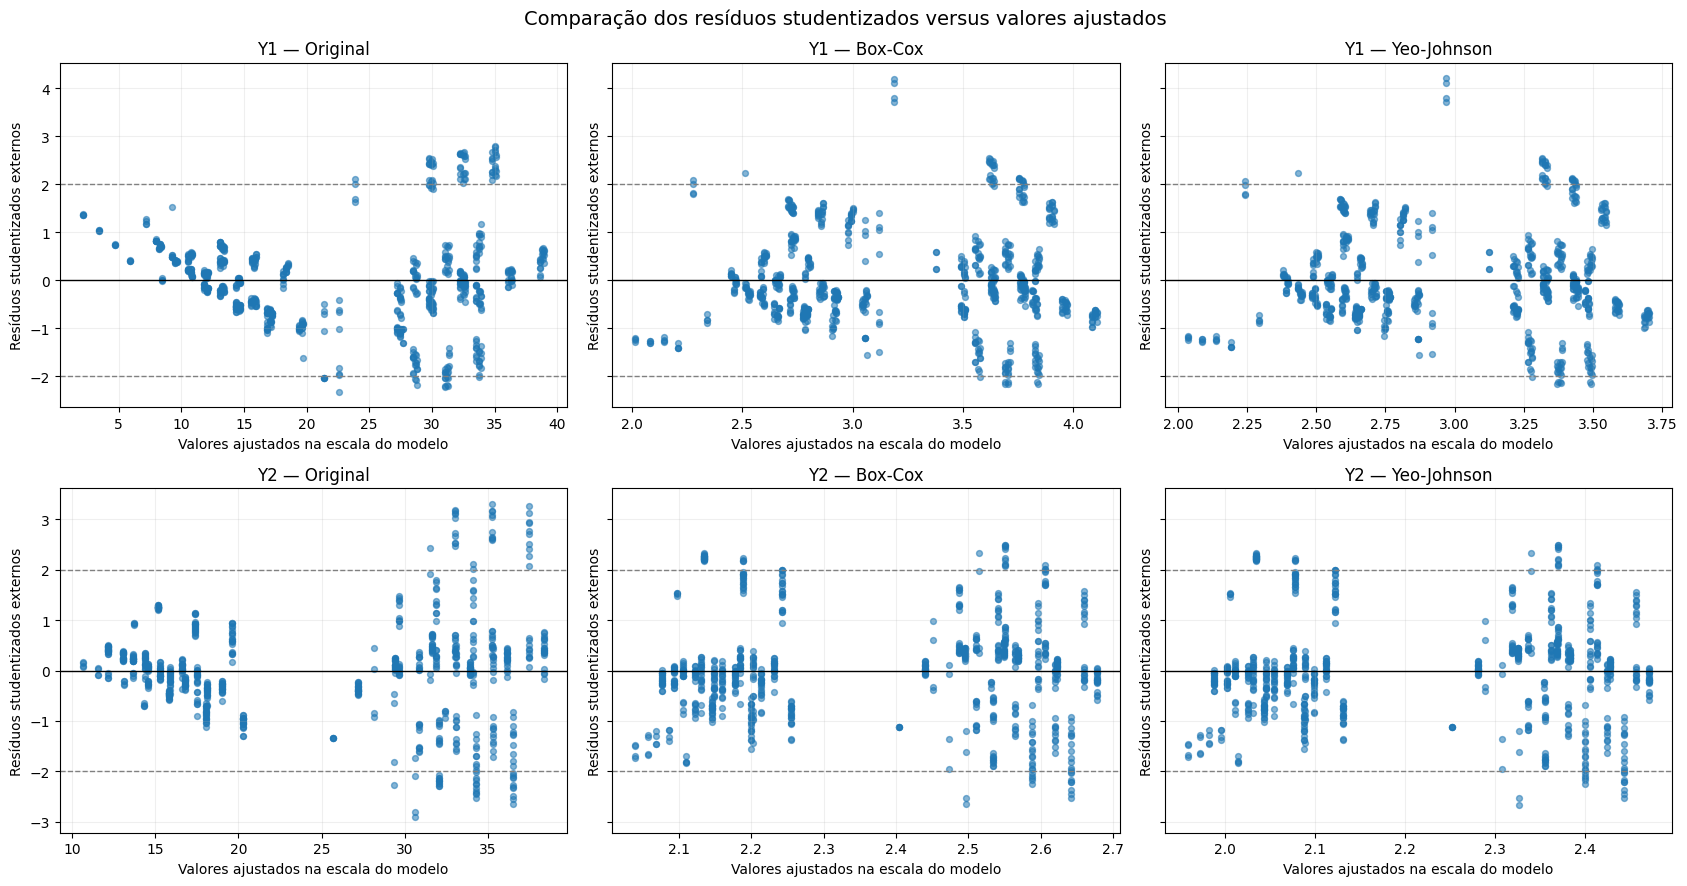

In [21]:
# Compara resíduos studentizados externamente versus ajustados para os modelos original, Box-Cox e Yeo-Johnson.
models_for_plots = {
    "Y1": {
        "Original": fitted_models["Y1"]["Modelo 122"],
        "Box-Cox": boxcox_models["Y1"],
        "Yeo-Johnson": yj_models["Y1"]
    },
    "Y2": {
        "Original": fitted_models["Y2"]["Modelo 17"],
        "Box-Cox": boxcox_models["Y2"],
        "Yeo-Johnson": yj_models["Y2"]
    }
}

fig, axes = plt.subplots(
    2, 3,
    figsize=(17, 9),
    sharey="row"
)

for row, response in enumerate(["Y1", "Y2"]):
    for col, (method, model) in enumerate(
        models_for_plots[response].items()
    ):
        ax = axes[row, col]

        # Calcula os resíduos studentizados externamente de cada ajuste.
        residuals = model.get_influence().resid_studentized_external

        ax.scatter(
            model.fittedvalues,
            residuals,
            alpha=0.55,
            s=18
        )

        ax.axhline(0, color="black", linewidth=1)
        ax.axhline(2, color="gray", linestyle="--", linewidth=1)
        ax.axhline(-2, color="gray", linestyle="--", linewidth=1)

        ax.set_title(f"{response} — {method}")
        ax.set_xlabel("Valores ajustados na escala do modelo")
        ax.set_ylabel("Resíduos studentizados externos")
        ax.grid(alpha=0.2)

fig.suptitle(
    "Comparação dos resíduos studentizados versus valores ajustados",
    fontsize=14
)
fig.tight_layout()
plt.show()

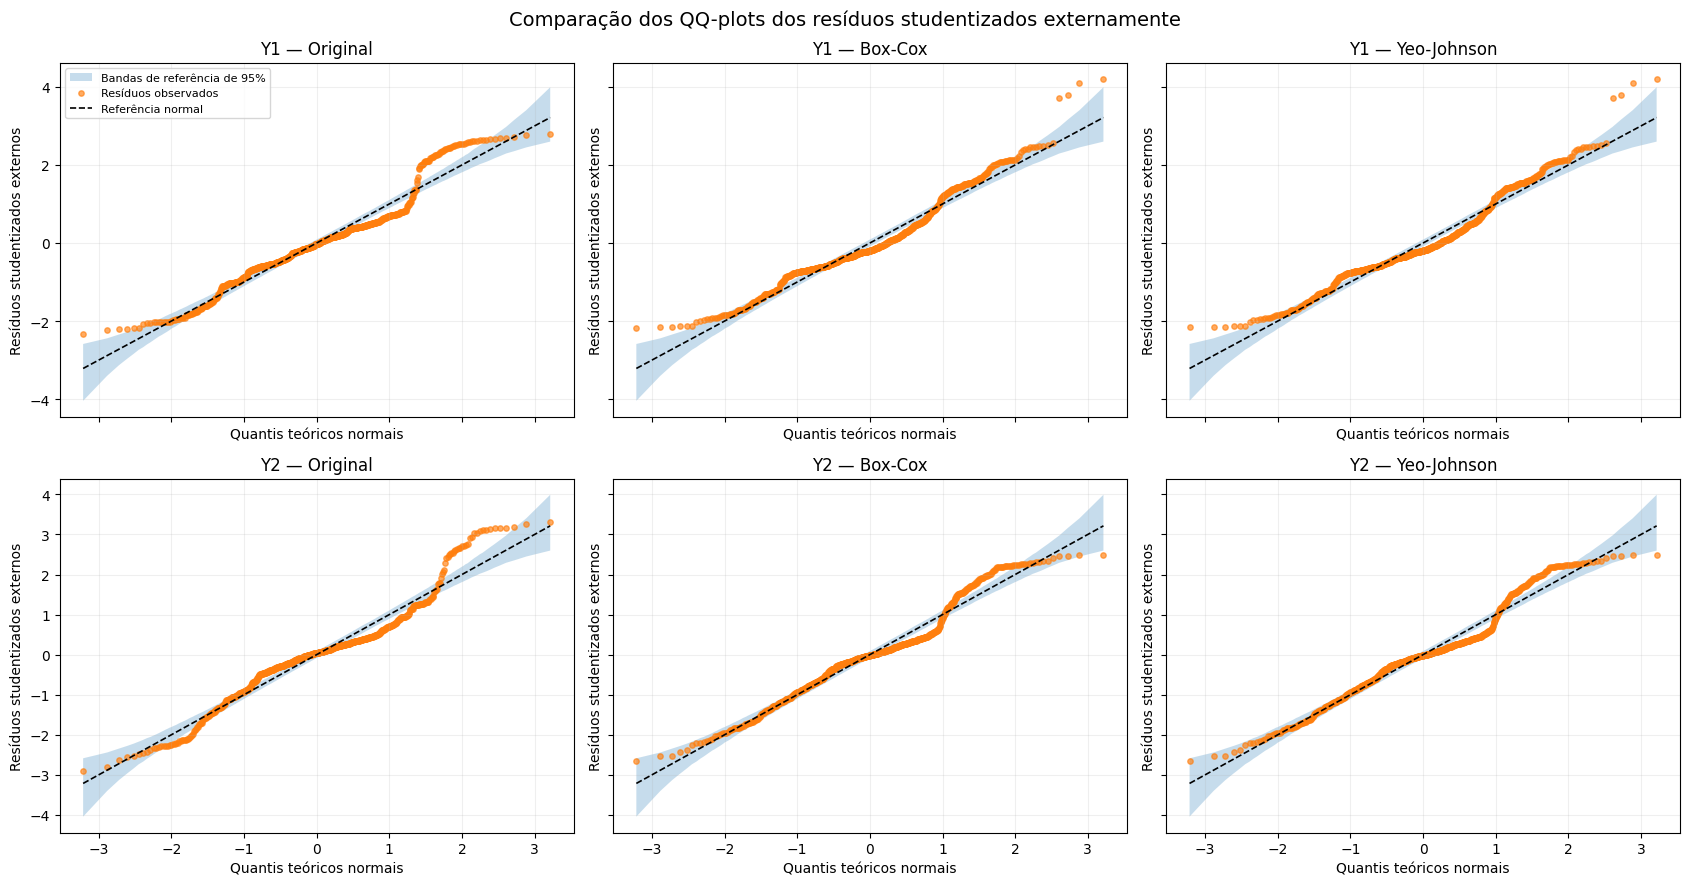

In [22]:
# Compara os QQ-plots dos resíduos studentizados externamente nos modelos original, Box-Cox e Yeo-Johnson.
fig, axes = plt.subplots(
    2, 3,
    figsize=(17, 9),
    sharex=True,
    sharey="row"
)

rng_qq = np.random.default_rng(2026)

# Gera quantis teóricos e bandas pontuais de referência sob normalidade.
n = len(df)
probabilities = (np.arange(1, n + 1) - 0.5) / n
theoretical = stats.norm.ppf(probabilities)

simulated_normal = np.sort(
    rng_qq.standard_normal(size=(3000, n)),
    axis=1
)
lower_band = np.quantile(simulated_normal, 0.025, axis=0)
upper_band = np.quantile(simulated_normal, 0.975, axis=0)

for row, response in enumerate(["Y1", "Y2"]):
    for col, (method, model) in enumerate(
        models_for_plots[response].items()
    ):
        ax = axes[row, col]

        # Ordena os resíduos studentizados externamente para o QQ-plot.
        residuals = model.get_influence().resid_studentized_external
        residuals = np.sort(residuals[np.isfinite(residuals)])

        ax.fill_between(
            theoretical,
            lower_band,
            upper_band,
            alpha=0.25,
            label="Bandas de referência de 95%"
        )

        ax.scatter(
            theoretical,
            residuals,
            s=15,
            alpha=0.65,
            label="Resíduos observados"
        )

        ax.plot(
            theoretical,
            theoretical,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="Referência normal"
        )

        ax.set_title(f"{response} — {method}")
        ax.set_xlabel("Quantis teóricos normais")
        ax.set_ylabel("Resíduos studentizados externos")
        ax.grid(alpha=0.2)

        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle(
    "Comparação dos QQ-plots dos resíduos studentizados externamente",
    fontsize=14
)
fig.tight_layout()
plt.show()

#### Interpretação gráfica das transformações

A comparação dos resíduos studentizados externamente versus valores ajustados mostrou que as transformações Box–Cox e Yeo–Johnson não eliminaram os padrões sistemáticos observados nos modelos originais. Para ambas as respostas, permaneceram agrupamentos de resíduos e sinais de dispersão não constante, sem evidência visual clara de correção da heterocedasticidade ou da possível inadequação funcional.

Nos QQ-plots, os resultados diferiram entre as respostas. Para $Y_1$, as transformações não proporcionaram melhora visual geral, com desvios mais acentuados na cauda superior da distribuição residual. Para $Y_2$, observou-se uma aproximação parcial à reta de referência, especialmente na cauda superior, embora ainda persistam desvios sistemáticos em relação à normalidade.

Essas observações são coerentes com os testes estatísticos realizados anteriormente: as transformações produziram melhorias pontuais, sobretudo na distribuição dos resíduos de $Y_2$, mas não resolveram conjuntamente os problemas identificados. A inspeção gráfica, portanto, reforça a decisão de não adotar as transformações como solução definitiva para as inadequações dos modelos.

## 3.8 Avaliação de uma especificação alternativa com interação

As análises anteriores identificaram padrões residuais associados a determinadas configurações geométricas, além de evidências de possível inadequação funcional nos modelos inicialmente selecionados. As transformações das respostas produziram melhorias limitadas, motivando a investigação de uma alternativa que represente possíveis relações conjuntas entre os preditores.

Nesta etapa, será avaliada a inclusão de uma interação entre $X_1$ e $X_3$, mantendo os efeitos principais dessas variáveis e os demais preditores da especificação aditiva correspondente. A comparação será realizada para $Y_1$ e $Y_2$, considerando os modelos-base, as alternativas aditivas já investigadas e as especificações com interação.

Serão examinados o $R^2$ ajustado, AIC, BIC, RMSE e o VIF máximo, além dos diagnósticos de heterocedasticidade, normalidade e forma funcional. A contribuição estatística do termo de interação será avaliada por meio de erro-padrão robusto HC3.

A interação será considerada uma alternativa candidata, não uma solução presumidamente superior. A decisão dependerá do ganho de ajuste, da contribuição da interação, da complexidade adicional e dos diagnósticos residuais. A escolha definitiva será apresentada na síntese final da modelagem.

In [23]:
# Compara os modelos-base, as alternativas aditivas e os modelos com interação X1:X3.
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import jarque_bera

df_interaction = df_model.copy()
df_interaction["X1_c"] = df["X1"] - df["X1"].mean()
df_interaction["X3_c"] = df["X3"] - df["X3"].mean()
df_interaction["X1_X3"] = df_interaction["X1_c"] * df_interaction["X3_c"]

interaction_specs = {
    "Y1": {
        "Modelo 122 — base": fit_mrlm("Y1", ["X3", "X5", "X7", "X8"]),
        "Aditivo — inclui X1": fit_mrlm(
            "Y1", ["X1", "X3", "X5", "X7", "X8"]
        )
    },
    "Y2": {
        "Modelo 17 — base": fit_mrlm("Y2", ["X1", "X5", "X7"]),
        "Aditivo — inclui X3": fit_mrlm(
            "Y2", ["X1", "X3", "X5", "X7"]
        )
    }
}

# Estima as especificações com interação, mantendo os efeitos principais.
interaction_specs["Y1"]["Interação X1:X3"] = sm.OLS(
    df["Y1"],
    sm.add_constant(
        df_interaction[
            ["X1_c", "X3_c", "X5", "X7", "X1_X3",
             "X8_1", "X8_2", "X8_3", "X8_4", "X8_5"]
        ]
    )
).fit()

interaction_specs["Y2"]["Interação X1:X3"] = sm.OLS(
    df["Y2"],
    sm.add_constant(
        df_interaction[["X1_c", "X3_c", "X5", "X7", "X1_X3"]]
    )
).fit()

comparison = []

for response, models in interaction_specs.items():
    for name, model in models.items():
        # Calcula o maior VIF entre os preditores, sem considerar o intercepto.
        exog_names = model.model.exog_names
        exog = model.model.exog

        vif_values = [
            variance_inflation_factor(exog, i)
            for i, term in enumerate(exog_names)
            if term.lower() not in {"const", "intercept"}
        ]

        # Aplica os testes de heterocedasticidade, normalidade e forma funcional.
        bp = het_breuschpagan(model.resid, exog, robust=True)
        jb_stat, jb_p, skew, kurtosis = jarque_bera(model.resid)

        reset = linear_reset(
            model,
            power=3,
            test_type="fitted",
            use_f=False,
            cov_type="HC3"
        )

        # Avalia a significância da interação usando erros-padrão robustos HC3.
        interaction_p_hc3 = np.nan

        if "X1_X3" in exog_names:
            robust_model = model.get_robustcov_results(cov_type="HC3")
            interaction_index = exog_names.index("X1_X3")
            interaction_p_hc3 = float(
                robust_model.pvalues[interaction_index]
            )

        comparison.append({
            "Resposta": response,
            "Modelo": name,
            "R² ajustado": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "RMSE": np.sqrt(np.mean(np.asarray(model.resid) ** 2)),
            "VIF máximo": max(vif_values),
            "p-valor interação (HC3)": interaction_p_hc3,
            "p-valor BP": bp[1],
            "p-valor JB": jb_p,
            "p-valor RESET (HC3)": float(reset.pvalue)
        })

comparison_table = pd.DataFrame(comparison)

# Exibe a comparação com precisão adequada para os valores-p.
display(
    comparison_table.style.format({
        "R² ajustado": "{:.4f}",
        "AIC": "{:.2f}",
        "BIC": "{:.2f}",
        "RMSE": "{:.4f}",
        "VIF máximo": "{:.3f}",
        "p-valor interação (HC3)": lambda x: (
            f"{x:.3e}" if pd.notna(x) else "—"
        ),
        "p-valor BP": "{:.3e}",
        "p-valor JB": "{:.3e}",
        "p-valor RESET (HC3)": "{:.3e}"
    })
)

,Resposta,Modelo,R² ajustado,AIC,BIC,RMSE,VIF máximo,p-valor interação (HC3),p-valor BP,p-valor JB,p-valor RESET (HC3)
0,Y1,Modelo 122 — base,0.9178,3819.95,3861.74,2.8757,3.927,—,4.007e-24,3.473e-13,1.691e-42
1,Y1,Aditivo — inclui X1,0.9202,3797.88,3844.32,2.8310,9.626,—,3.259e-73,1.236e-03,2.396e-36
2,Y1,Interação X1:X3,0.9272,3728.37,3779.45,2.7022,12.683,1.176e-51,1.519e-70,5.681e-06,2.101e-21
3,Y2,Modelo 17 — base,0.8815,4005.66,4024.23,3.2665,3.176,—,4.332e-32,6.684e-22,9.719e-08
4,Y2,Aditivo — inclui X3,0.8836,3992.60,4015.82,3.2346,9.626,—,4.547e-41,1.003e-33,4.575e-18
5,Y2,Interação X1:X3,0.8938,3923.33,3951.20,3.0879,12.683,1.133e-34,2.856e-41,4.158e-52,2.266e-11


### Interpretação da comparação entre as especificações

A comparação indicou melhora no ajuste dos modelos com interação entre $X_1$ e $X_3$, em relação às especificações aditivas correspondentes. Para $Y_1$, o $R^2$ ajustado aumentou de 0,9202 para 0,9272, enquanto o RMSE diminuiu de 2,8310 para 2,7022. Para $Y_2$, o $R^2$ ajustado passou de 0,8836 para 0,8938, e o RMSE caiu de 3,2346 para 3,0879. A redução do AIC também favoreceu as especificações com interação nas duas respostas.

Além disso, o termo de interação apresentou valores-p muito pequenos quando avaliado com erros-padrão robustos HC3, indicando evidência estatística de sua contribuição nas especificações analisadas.

Entretanto, o VIF máximo aumentou para 12,683 nos modelos com interação, indicando possível preocupação com a estabilidade das estimativas devido à multicolinearidade. Os testes de Breusch–Pagan, Jarque–Bera e Ramsey RESET também permaneceram significativos, de modo que a inclusão da interação não eliminou as inadequações apontadas pelos diagnósticos.

Assim, a interação entre $X_1$ e $X_3$ mostrou-se uma alternativa promissora para melhorar o ajuste dos modelos, mas seus ganhos devem ser ponderados diante da maior colinearidade e da persistência dos problemas residuais. A escolha da especificação a ser apresentada como resultado final será consolidada na síntese da modelagem.

## 3.9 Síntese final do projeto

Este projeto analisou dados de eficiência energética de edificações, considerando as respostas *Heating Load* $(Y_1)$ e *Cooling Load* $(Y_2)$. Inicialmente, foram realizadas a preparação dos dados e a análise exploratória, seguidas da seleção de modelos de Regressão Linear Múltipla com base em critérios de ajuste e parcimônia. Nessa etapa, foram selecionados o Modelo 122 para $Y_1$, com preditores $X_3$, $X_5$, $X_7$ e $X_8$, e o Modelo 17 para $Y_2$, com preditores $X_1$, $X_5$ e $X_7$.

A etapa de diagnóstico identificou evidências de heterocedasticidade, desvios da normalidade dos resíduos e possível inadequação da forma funcional. A investigação das observações potencialmente influentes não revelou justificativa concreta para excluir registros, que foram mantidos. As transformações Box–Cox e Yeo–Johnson produziram melhorias limitadas, sem resolver conjuntamente os problemas identificados.

Por fim, foi investigada uma especificação com interação entre $X_1$ e $X_3$. Em comparação com as alternativas aditivas, essa especificação apresentou melhor ajuste para ambas as respostas: o $R^2$ ajustado aumentou para 0,9272 em $Y_1$ e 0,8938 em $Y_2$, enquanto o RMSE diminuiu para 2,7022 e 3,0879, respectivamente. A interação também apresentou contribuição estatística significativa com erros-padrão robustos HC3. Entretanto, o aumento do VIF máximo para 12,683 e a persistência dos problemas residuais indicam que esses modelos não devem ser considerados plenamente adequados.

Assim, os modelos com interação constituem as alternativas de melhor ajuste entre as especificações avaliadas, mas sua utilização deve considerar as limitações de multicolinearidade e diagnóstico. Conclui-se que a modelagem permitiu identificar relações relevantes e comparar sistematicamente diferentes especificações, sem que fosse possível satisfazer integralmente todos os critérios de adequação. Essas limitações devem ser consideradas na interpretação dos coeficientes e no uso dos modelos para inferência ou previsão.